## Libaries

In [2]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import json
import re
import pandas as pd
import mne

parent_dir = Path().resolve().parent
sys.path.append(str(parent_dir))

from utilities.preprocessing import EEG_preprocessing, EMG_preprocessing       # noqa: E402

'''
MVC does increase Extensor muscles more then the raw data. Maybe the calibration needs to be adjusted.
'''

'\nMVC does increase Extensor muscles more then the raw data. Maybe the calibration needs to be adjusted.\n'

## Global variables

In [2]:
EMG_FREQ = 2000
EEG_FREQ = 125
NUM_EPOCH = 35 * 3
TRIAL_PERIOD = 9

EEG_CH_NAMES = [
    "Fp1", "Fp2",   # frontal pole
    "C3",  "C4",    # central
    "T5",  "T6",    # temporal (posterior)
    "Cz",  "Pz",    # occipital
    "F7",  "F8",    # temporal (anterior)
    "F3",  "F4",    # frontal
    "T3",  "T4",    # temporal (mid)
    "P3",  "P4"     # parietal
]
EMG_CH_NAMES = [
'Channel 1 : Flexor pollicis longus',
'Channel 2 : Flexor digitorum superficialis',
'Channel 3 : ',
'Channel 4 : ',
'Channel 5 : ',
'Channel 6 : '
]

# EMG_CH_NAMES = [
# 'Channel 1 : Flexor digitorum superficialis',
# 'Channel 2 : Flexor pollicis longus', 
# 'Channel 3 : Extensor digitorum',
# 'Channel 4 : Extensor pollicis brevis/longus'
# ]

In [111]:
# ----- Global style -----

plt.rcParams.update({
    # ---- Font ----
    "font.family": "serif",
    #"font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    #"mathtext.fontset": "stix",
    #"text.usetex": False,          # True for LaTeX rendering (optional)
    
    # ---- Font sizes (A4 layout, 10 pt doc) ----
    "font.size": 9,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    
    # ---- Line and color ----
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.5,
    "lines.markersize": 4,
    "axes.prop_cycle": plt.cycler(color=plt.cm.tab10.colors),

    # ---- Layout ----
    # Page size (247.000, 174.000) height, width
    # (5.5, 3.5) half-page 
    #"figure.figsize": (5.5, 3.5),  
    "figure.dpi": 400,
    "savefig.transparent": True,
    "savefig.bbox": "tight"
})

def mm_to_inches(mm):
    return mm / 25.4

## Import data

In [5]:
choise_subject_file = 'Nicklas_wrist_EMG'
#choise_data_file = '2025-11-03 09-32-34'

## Load multiple csv files

In [6]:
def load_multi_csv(csv_files, data_type=None):
    dfs = []
    for f in csv_files:
        # Extract finger name only
        # r'imp_con_(.*?)_grip_'
        match = re.search(r'flex_(.*?)_finger_', f.stem)
        finger = match.group(1) if match else 'unknown'                

        if data_type == 'EEG':
            df = pd.read_csv(f, delimiter=',')    
            #df = pd.read_csv(f, delim_whitespace=True)
        else:
            df = pd.read_csv(f)
        df['finger'] = finger
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

sf = 'flex_*_finger_*.csv'
#sf = 'imp_con_*_grip_*.csv'

# For EMG
EMG_data_dir = Path(fr'data\{choise_subject_file}\EMG')
csv_files = list(EMG_data_dir.glob(sf))          # Find path to all files of this name

EMG_raw_df = load_multi_csv(csv_files)

EEG_data_dir = Path(fr'data\{choise_subject_file}\EEG')
csv_files = list(EEG_data_dir.glob(sf))          # Find path to all files of this name

EEG_raw_df = load_multi_csv(csv_files, data_type='EEG')

# For markers
markers_data_dir = Path(fr'data\{choise_subject_file}\Markers')
csv_files = list(markers_data_dir.glob(sf))          # Find path to all files of this name

markers_df = load_multi_csv(csv_files)

EMG_raw = {
    f: EMG_raw_df.loc[EMG_raw_df['finger'] == f, EMG_raw_df.columns.str.startswith('ch')].to_numpy()
    for f in EMG_raw_df['finger'].unique()
}

EEG_raw = {
    f: EEG_raw_df.loc[EEG_raw_df['finger'] == f, EEG_raw_df.columns.str.startswith(' EXG')].to_numpy()
    for f in EEG_raw_df['finger'].unique()
}

markers = {
    f: markers_df.loc[markers_df['finger'] == f]
    for f in EEG_raw_df['finger'].unique()
}

EMG_NUM_CH = EMG_raw['index'].shape[1]
EEG_NUM_CH = EEG_raw['index'].shape[1]

In [68]:
# TEMPORARY REMOVE OTHER THAN INDEX AND THUMB
temp_EMG = {}
for key in EMG_raw.keys():
    if key in ['index', 'thumb']:
        temp_EMG[key] = EMG_raw[key]
        
EMG_raw = temp_EMG
print(EEG_raw.keys(), EMG_raw.keys(), markers.keys())
print(f"EMG_CH_NAMES shape: {EMG_NUM_CH}\n"
      f"EMG samples {EMG_raw['index'].shape[0]}\n"
      f"EEG_CH_NAMES shape: {EEG_NUM_CH}\n"
      f"EEG samples {EEG_raw['index'].shape[0]}")


dict_keys(['index', 'thumb']) dict_keys(['index', 'thumb']) dict_keys(['index', 'thumb'])
EMG_CH_NAMES shape: 6
EMG samples 1890000
EEG_CH_NAMES shape: 16
EEG samples 118186


## EMG Section

### Normalization functions

In [16]:
def MVC_EMG(json_filepath, EMG_raw):
    with open(fr'data\{json_filepath}') as f:
        calib_read = json.load(f)

    calib_dist = {}
    EMG_calib = []

    
    for k, (ch, value) in enumerate(calib_read.items()):
        ref = value['baseline_noise']
        mvc = value['MVC']
        print(f'baseline: {ref} \n mvc: {mvc}')
        
    
        calib_dist[ch] = {
            'ref' : ref,
            'mvc' : mvc
        }

        #print(f"{ch}: baseline={ref}, mvc={mvc}")
        
        if isinstance(EMG_raw, pd.DataFrame):
            normalized = ((EMG_raw.values[:, k] - ref) / (mvc - ref)) * 100
            EMG_calib.append(normalized)
            
        else:
            normalized = (EMG_raw[:, k] - ref) / (mvc - ref) * 100
            EMG_calib.append(normalized)
        
    EMG_calib = np.array(EMG_calib).T

    return EMG_calib

def zscore_within_channel(eeg):
    """
    eeg: np.ndarray of shape (samples, channels)
    returns z-scored EEG per channel
    """
    
    eeg_return = []
    mean = np.mean(eeg, axis=0, keepdims=False)
    std  = np.std(eeg, axis=0, keepdims=False)

           
    if len(eeg.shape) == 1:
        eeg_return.append( (eeg[:] - mean) / (std + 1e-8) )
        return np.array(eeg_return).T

    for i in range(eeg.shape[1]):
        eeg_return.append( (eeg[:, i] - mean[i]) / (std[i] + 1e-8) )
    
    return np.array(eeg_return).T

def robust_within_channel(eeg):
    """
    eeg: (channels, samples)
    returns robust-scaled EEG per channel (less sensitive to outliers)
    """
    med = np.median(eeg, axis=0, keepdims=True)
    q75 = np.quantile(eeg, 0.75, axis=0, keepdims=True)
    q25 = np.quantile(eeg, 0.25, axis=0, keepdims=True)
    iqr = q75 - q25
    return (eeg - med) / (iqr + 1e-8)

def normalize_EMG(data):
    '''
    data: np.ndarray of shape (samples, channels)
    '''
    EMG_calib = []
    for k in range(data.shape[1]):
        ch_data = data[:, k]
        min_data = np.min(ch_data)
        max_data = np.max(ch_data)
        normalized = (ch_data - min_data) / (max_data - min_data)
        EMG_calib.append(normalized)
    EMG_calib = np.array(EMG_calib).T
    
    return EMG_calib

def common_average_reference(eeg):
    """
    eeg: np.ndarray of shape (samples, channels)
    returns CAR referenced EEG
    """
    avg = np.mean(eeg, axis=1, keepdims=True)
    eeg_car = eeg - avg
    
    return eeg_car

## Plot EMG

In [ ]:
def add_markers_to_plot(marker_file, marker_mode = None):
    """
    Reads marker CSV and adds vertical lines + labels at each time.
    CSV must have columns: time, marker_id, description

    args:
        marker_mode: 
            Set to 'continuous' for adding all markers to plot
            Set to 'epoch' and define number of markers to plot
    """

    for i, row in enumerate(marker_file.values):
        t = row[0]
        marker = row[1]
        desc = {
            10 : 'rest',
            20 : 'contract',
            30 : 'release',
            0  : 'end'
            }

        # vertical line
        plt.axvline(x=t, color='salmon', linestyle='--', alpha=0.5)

        # label text above line
        plt.text(
            t, plt.ylim()[1]*0.9, f'{desc[marker]}',
            rotation=90, color='salmon', ha='left', va='top', fontsize=10
        )

        if marker_mode is not None:
            if marker_mode - 1 == i:
                break

def plot_emg_mean_epoch_single_channels(emg_epoch_mean, rms_epoch_mean, ch1 = 0, ch2 = 1, key1 = None, key2 = None):

    fig, axs = plt.subplots(
    1, 2,
    figsize=(mm_to_inches(162), mm_to_inches(70)),      # Before 162, 60
    dpi=400,                     # IMPORTANT
    gridspec_kw={"wspace": 0.05}, # spacing between figures
    sharey=True
    )
    #print('Channel Name :', EMG_CH_NAMES[emg_ch], 'and', EMG_CH_NAMES[rms_ch])

    emg1 = np.array(emg_epoch_mean[key1][:, ch1])
    rms1 = np.array(rms_epoch_mean[key1][:, ch1])

    emg2 = np.array(emg_epoch_mean[key2][:, ch2])
    rms2 = np.array(rms_epoch_mean[key2][:, ch2])

    time = np.arange(emg1.shape[0]) / EMG_FREQ
    RMS_window_size = int(0.1 * EMG_FREQ)  # 100 ms
    win_time = (np.arange(rms1.shape[0]) * (RMS_window_size/4) + RMS_window_size/4) / EMG_FREQ


    axs[0].plot(time, emg1, color='royalblue', linewidth=1.0, label = 'Index finger')
    axs[0].plot(win_time, rms1, color = 'orange', linewidth = 1.0, label = 'RMS envelope')
    axs[0].set_xlim([0, 9])
    axs[0].set_ylim([-2, 2])
    axs[0].set_xticks(np.arange(0.0, 9.01, 1.0))
    axs[0].set_xlabel('Time (s)')
    axs[0].set_ylabel('Standardized EMG (a.u)')
    axs[0].axvline(2, color='salmon', linestyle='--', linewidth=1.0)
    axs[0].axvline(7, color='salmon', linestyle='--', linewidth=1.0)
    axs[0].grid(True, alpha=0.3)
    axs[0].legend(loc = 'lower left')

    axs[0].text(2, plt.ylim()[1]*0.99, 'Contract', rotation=90, color='salmon', ha='left', va='top', fontsize=8)
    axs[0].text(7, plt.ylim()[1]*0.99, 'Release', rotation=90, color='salmon', ha='left', va='top', fontsize=8)

    axs[1].plot(time, emg2, color='royalblue', linewidth=1.0, label='Thumb')
    axs[1].plot(win_time, rms2, color = 'orange', linewidth = 1.0, label = 'RMS envelope')
    axs[1].set_xlim([0, 9])
    axs[1].set_xticks(np.arange(0.0, 9.01, 1.0))
    axs[1].set_xlabel('Time (s)')
    axs[1].axvline(2, color='salmon', linestyle='--', linewidth=1.0)
    axs[1].axvline(7, color='salmon', linestyle='--', linewidth=1.0)
    axs[1].grid(True, alpha=0.3)
    axs[1].legend(loc = 'lower left')

    axs[1].text(2, plt.ylim()[1]*0.99, 'Contract', rotation=90, color='salmon', ha='left', va='top', fontsize=8)
    axs[1].text(7, plt.ylim()[1]*0.99, 'Release', rotation=90, color='salmon', ha='left', va='top', fontsize=8)
    
    #plt.savefig(fr'images\Nicklas_wrist_EMG\Mean_EEG_epoch_{key1}_ch{ch1}_and_{key2}_ch{ch2}_report.pdf')

In [17]:
EMG_pre_ins = EMG_preprocessing(fs = EMG_FREQ)
EEG_pre_ins = EEG_preprocessing(fs = EEG_FREQ)

RMS, RMS_epoch, RMS_epoch_mean = EMG_pre_ins.preprocessing_routine_rms(raw_emg = EMG_raw,
                                                        bandpass_lowcut = 20,
                                                        bandpass_highcut = 450,
                                                        num_channels = 2,
                                                        num_epochs = 10,
                                                        trial_period = 9,
                                                        sample_window = 200,
                                                        window_stepsize = 50)

EMG, EMG_epoch, EMG_epoch_mean = EMG_pre_ins.preprocessing_routine(raw_emg = EMG_raw,
                                                        bandpass_lowcut = 20,
                                                        bandpass_highcut = 450,
                                                        num_channels = 2,
                                                        num_epochs = 10,
                                                        trial_period = 9)

For finger motion: index
Total Time 90 s
Real fs: 39.96666666666667 Hz
Ceil fs: 40 Hz
Target len: 3600
RMS len before resample: (3597, 2)
EMG original len: 180000
RMS resample shape: (3600, 2)
RMS epoch shape: (10, 360, 2)
RMS mean epoch shape: (360, 2)

For finger motion: thumb
Total Time 90 s
Real fs: 39.96666666666667 Hz
Ceil fs: 40 Hz
Target len: 3600
RMS len before resample: (3597, 2)
EMG original len: 180000
RMS resample shape: (3600, 2)
RMS epoch shape: (10, 360, 2)
RMS mean epoch shape: (360, 2)

For finger motion: index
Total Time 90 s
Real fs: 2000.0 Hz
Target len: 180000
EMG original len: 180000
EMG resample shape: (180000, 2)
EMG epoch shape: (10, 18000, 2)
EMG mean epoch shape: (18000, 2)

For finger motion: thumb
Total Time 90 s
Real fs: 2000.0 Hz
Target len: 180000
EMG original len: 180000
EMG resample shape: (180000, 2)
EMG epoch shape: (10, 18000, 2)
EMG mean epoch shape: (18000, 2)



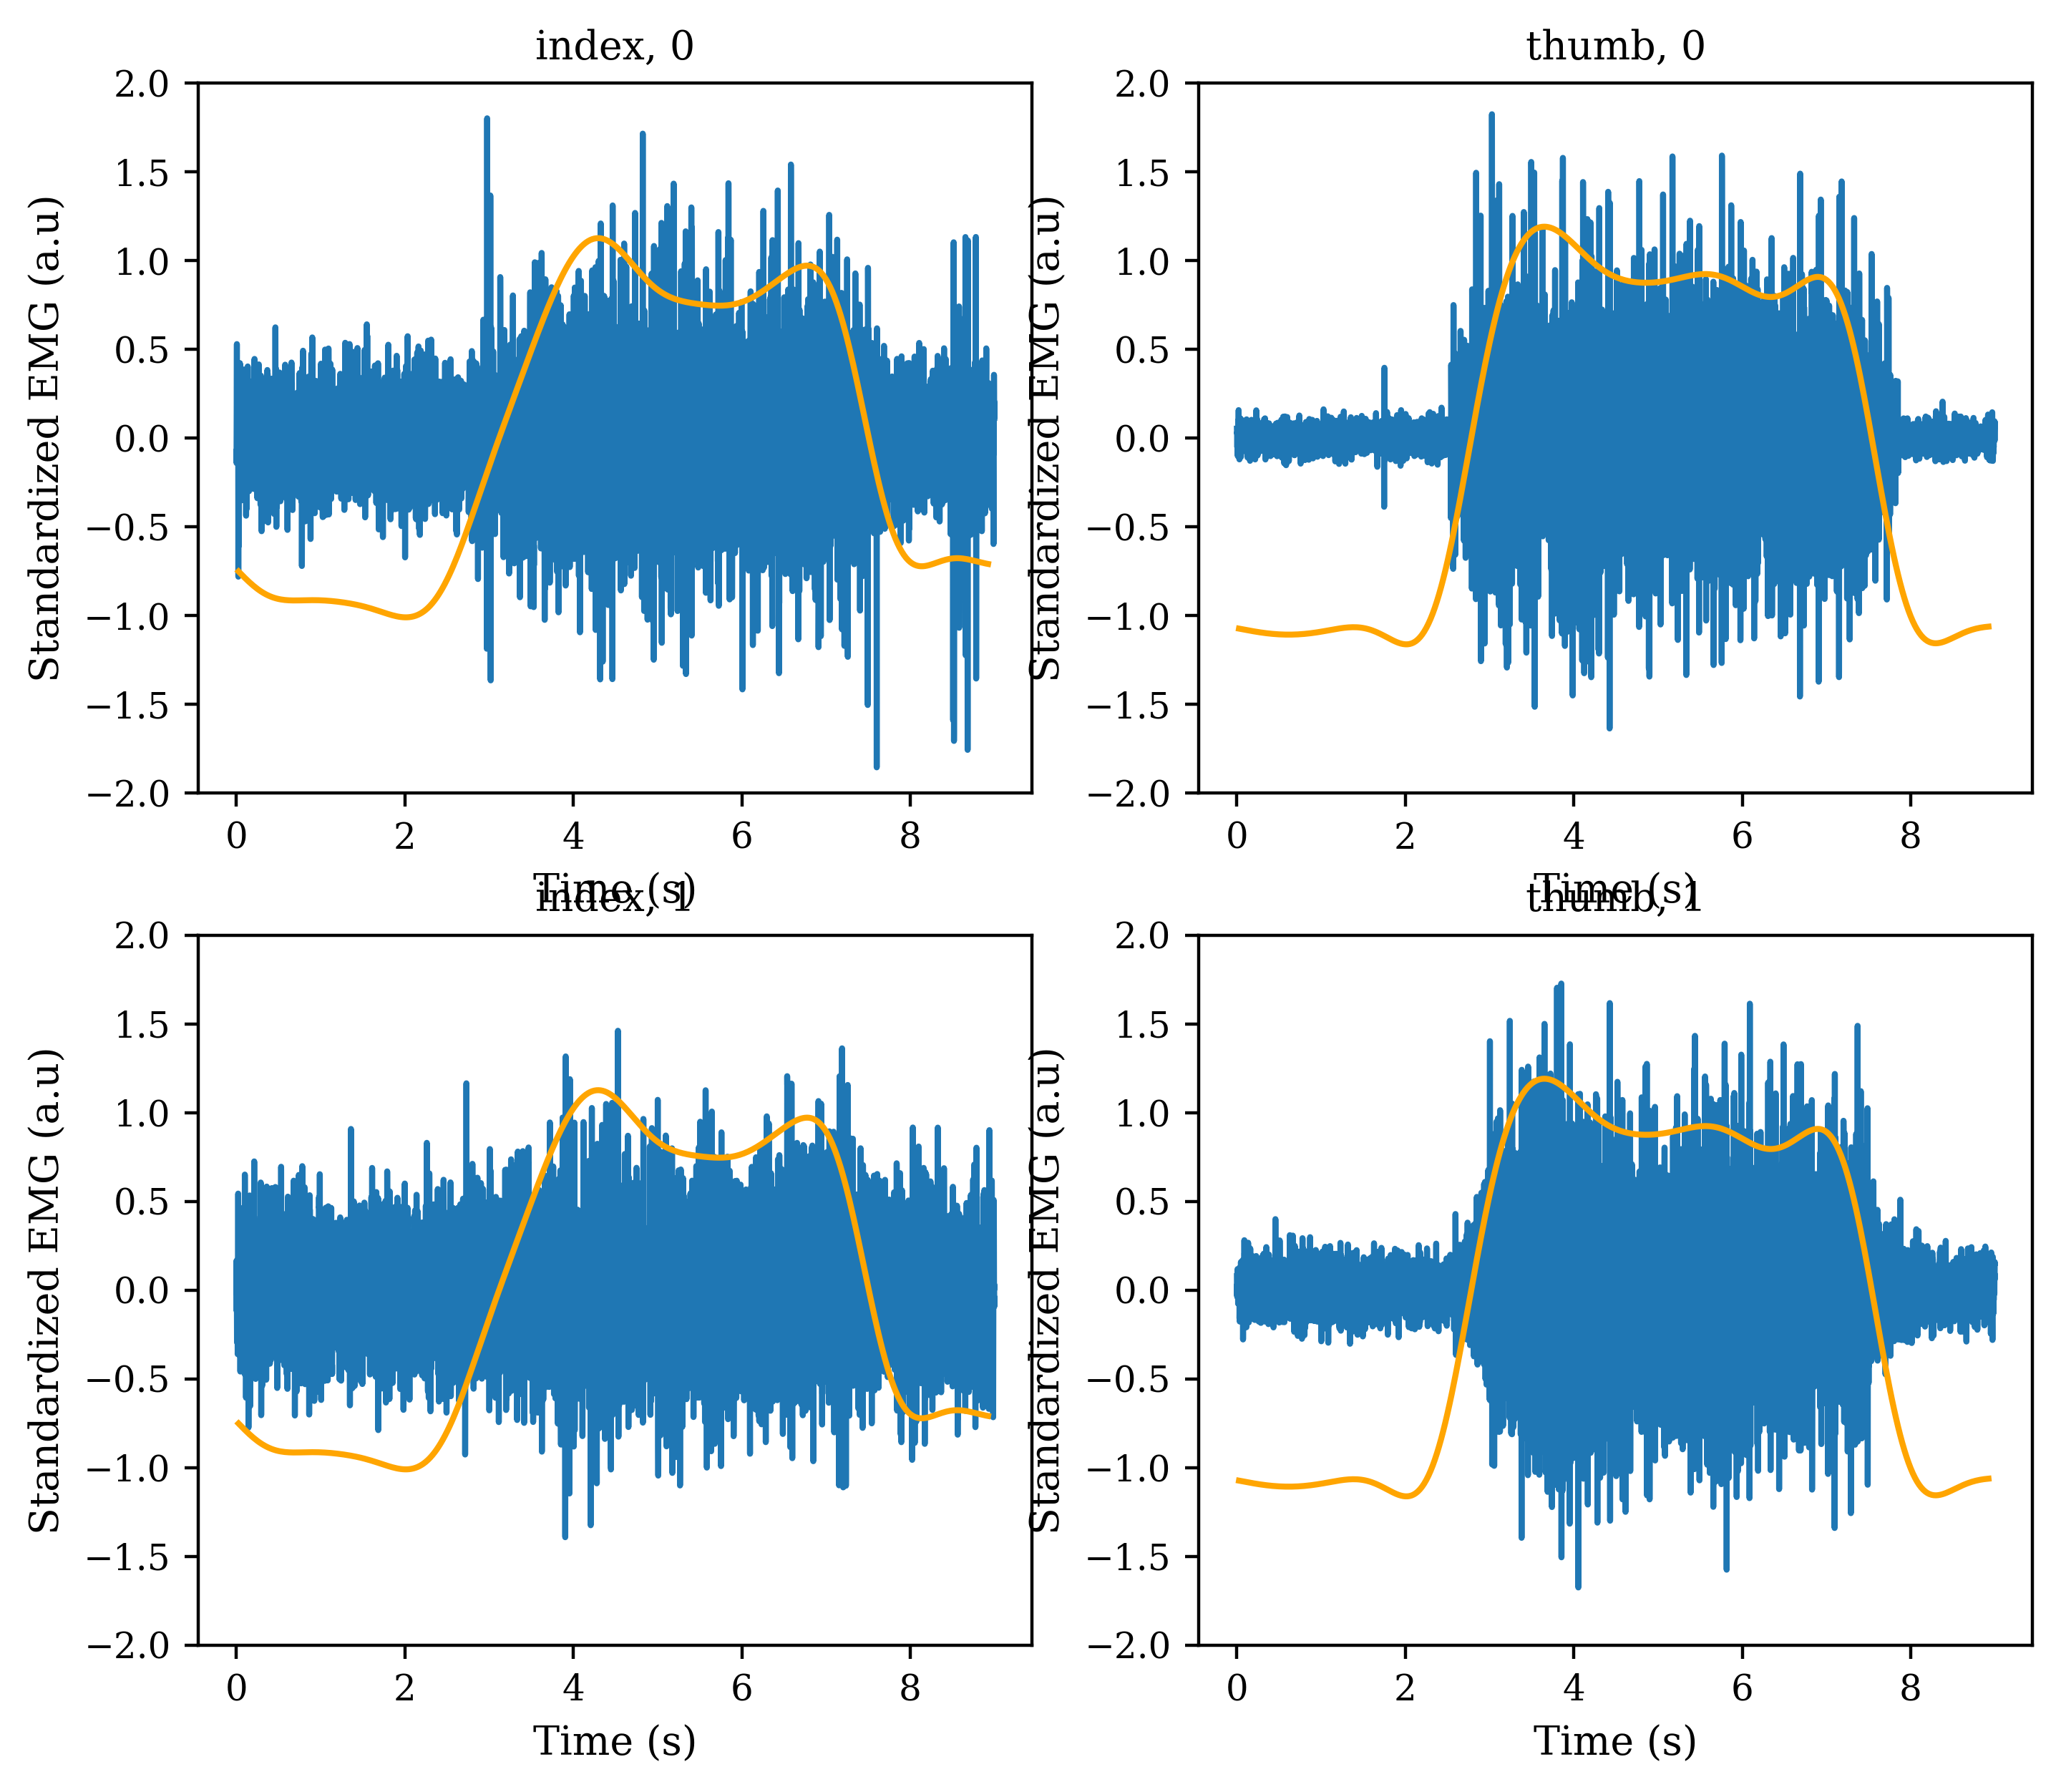

In [96]:
time = np.arange(EMG_epoch['index'].shape[1]) / EMG_FREQ
RMS_window_size = int(0.1 * EMG_FREQ)  # 100 ms
win_time = (np.arange(RMS_epoch['index'].shape[1]) * (RMS_window_size/4) + RMS_window_size/4) / EMG_FREQ

fig, axs = plt.subplots(2, 2, figsize=(mm_to_inches(210), mm_to_inches(180)), dpi=400)  # Before 210, 160
for ch in range(2):
    for i, key in enumerate(EMG_epoch.keys()):
        axs[ch, i].plot(time, EMG_epoch_mean[key][:, ch], label='Z-scored EMG')
        axs[ch, i].plot(win_time, RMS_epoch_mean[key][:, ch], label='RMS EMG', color='orange')
        axs[ch, i].set_xlabel('Time (s)')
        axs[ch, i].set_ylabel('Standardized EMG (a.u)')
        axs[ch, i].set_title(f'{key}, {ch}')
        axs[ch, i].set_ylim([-2, 2])

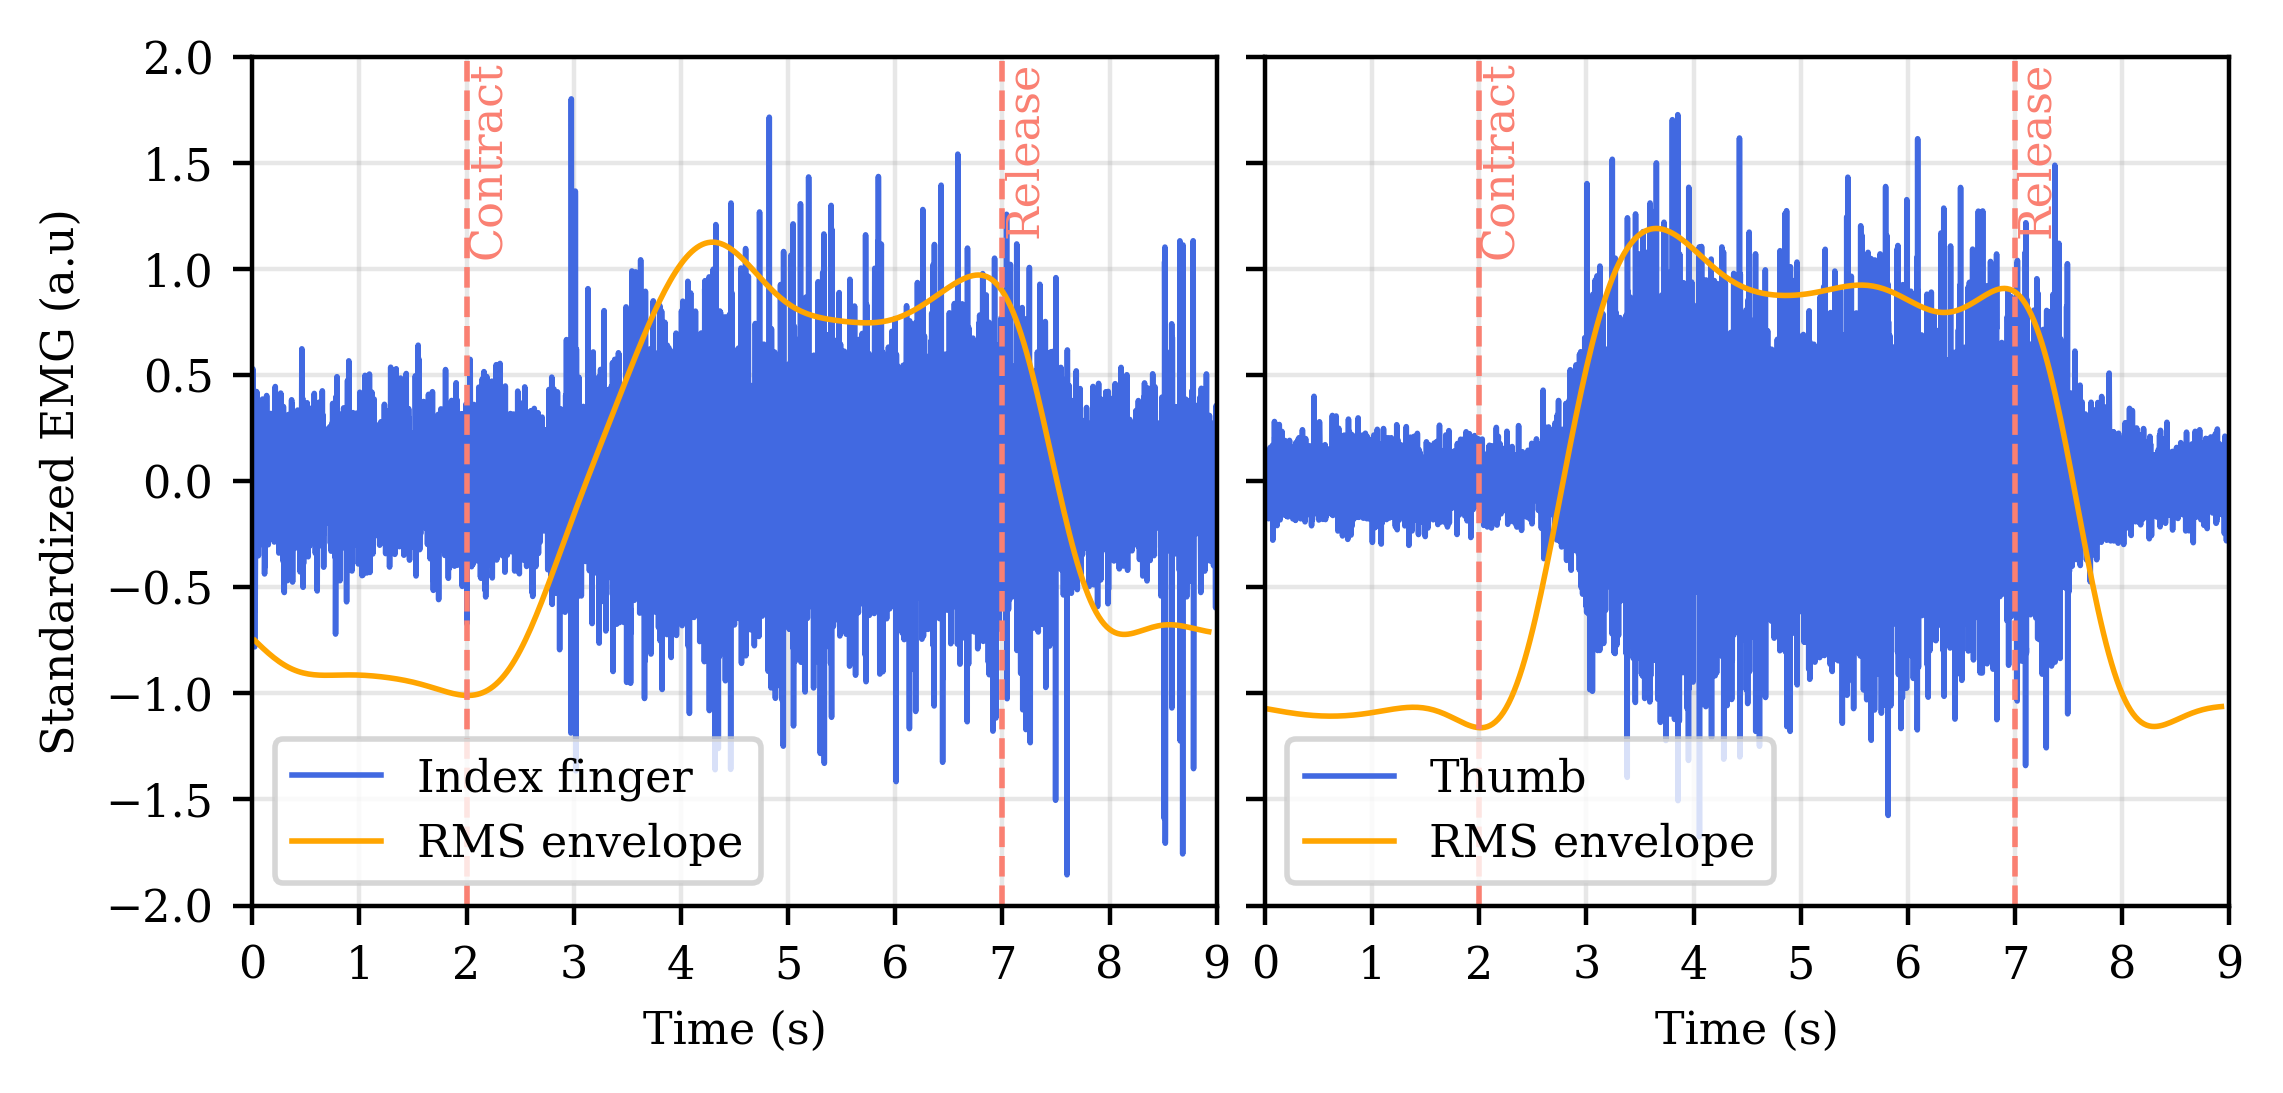

In [108]:
plot_emg_mean_epoch_single_channels(EMG_epoch_mean, RMS_epoch_mean, ch1 = 0, ch2 = 1, key1 = 'index', key2 = 'thumb')

## Box plot

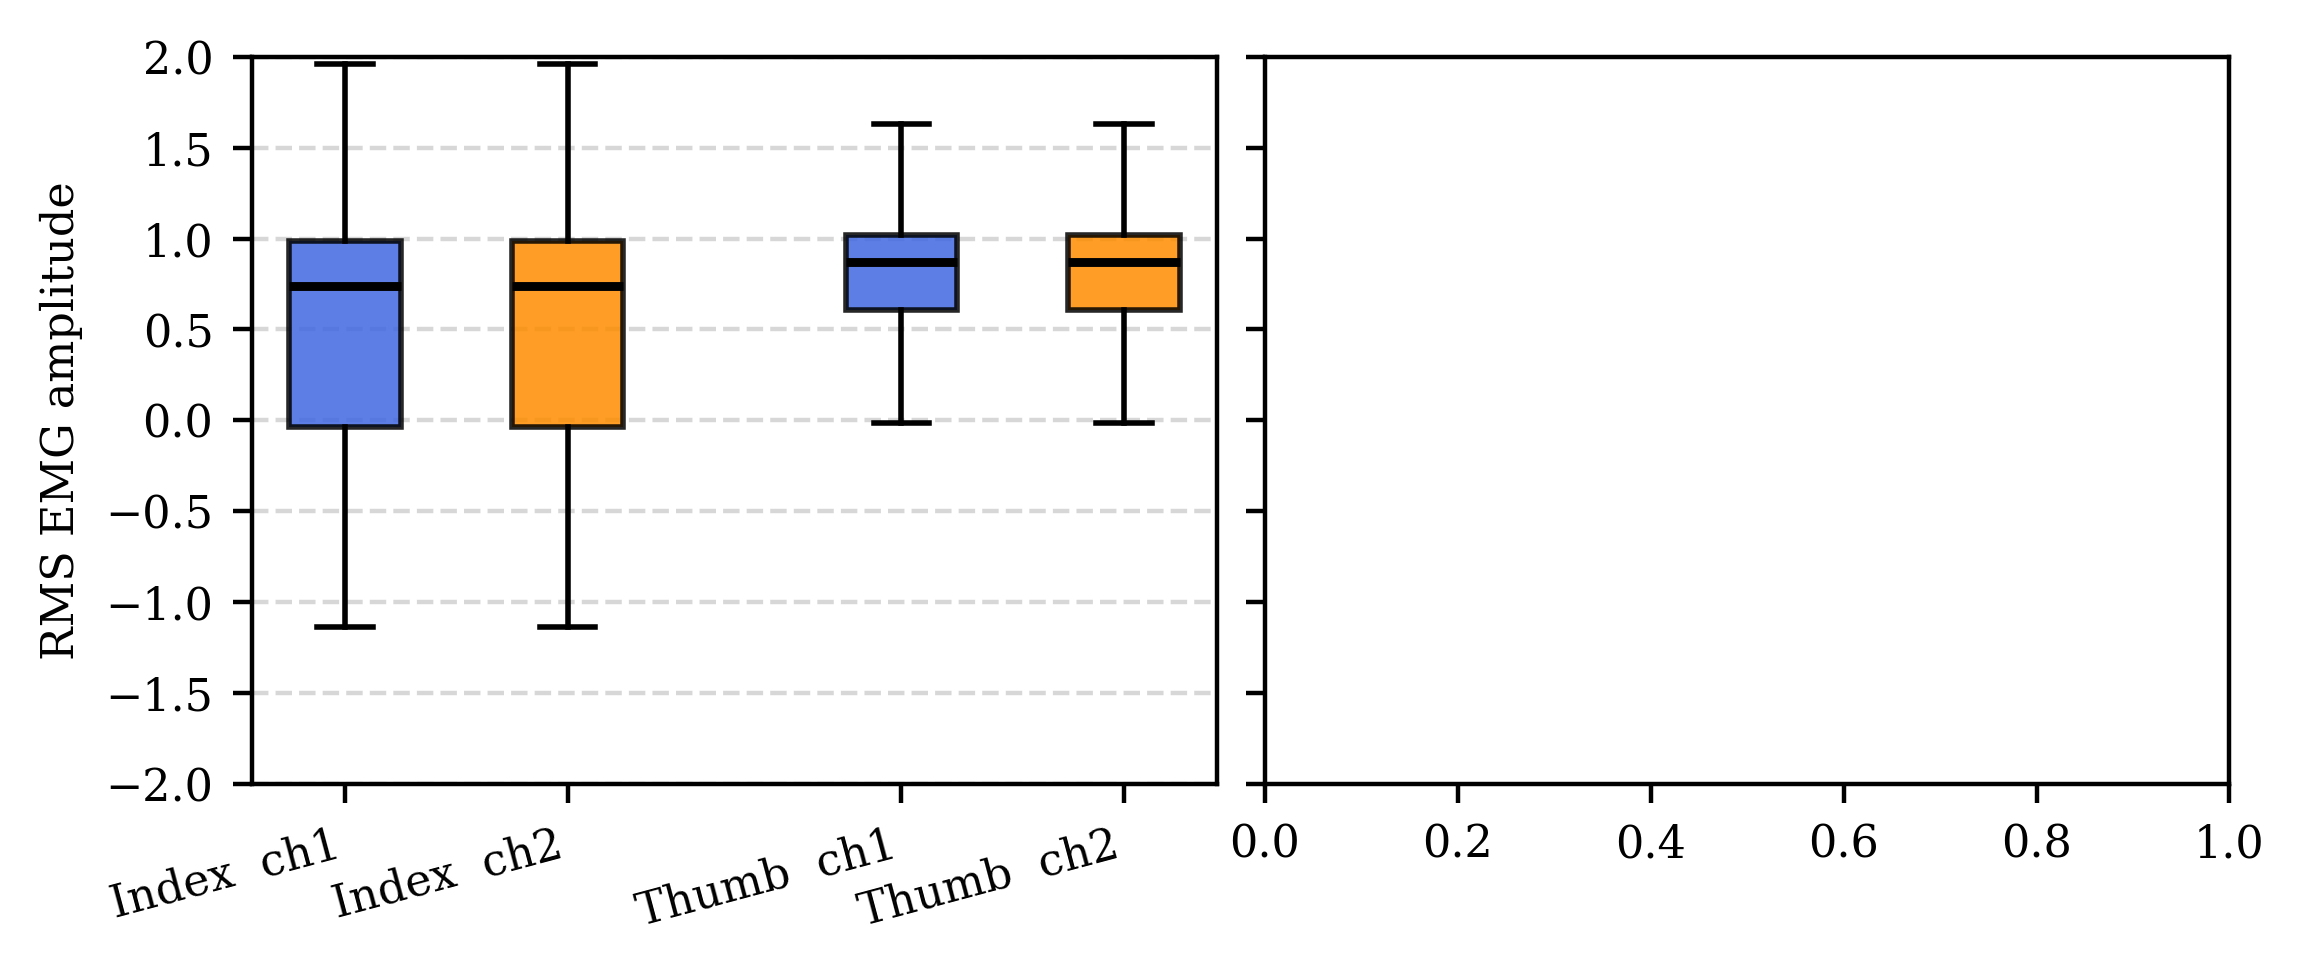

In [173]:
def box_plot_across_channels(epoch_data, range_of_interst = 0):
    
    fingers = list(epoch_data.keys())
    n_ch = epoch_data[fingers[0]].shape[2]

    group_spacing = 1.2      # spacing between channels inside a finger-group
    finger_spacing = n_ch + 1 # spacing between finger groups

    if isinstance(range_of_interst, int):
        range_of_interst = np.arange(0, epoch_data[fingers[0]].shape[1])
        print('enter')

    # colors = [
    #     'royalblue',   # thumb
    #     'darkorange',  # index
    #     'forestgreen', # middle
    #     'firebrick',   # ring
    #     'purple',      # little
    #     'saddlebrown'  # palm
    # ]
    channel_colors = [
        'royalblue',   # thumb
        'darkorange',  # index
    ]
    flierprops=dict(
        marker='*',
        markersize=0.5,
        markerfacecolor='black',
        markeredgecolor='black',
        alpha=0.6
    )

    positions = []
    labels = []
    all_box_data = []

    #plt.figure(figsize=(mm_to_inches(162/2), mm_to_inches(60)))
    fig, axs = plt.subplots(
    1, 2,
    figsize=(mm_to_inches(162), mm_to_inches(60)),      # Before 162, 60
    dpi=400,                     # IMPORTANT
    gridspec_kw={"wspace": 0.05}, # spacing between figures
    sharey=True
    )

    for f_idx, finger in enumerate(fingers):

        # data shape = (epochs, samples, channels)
        n_epo, n_sam, n_ch = epoch_data[finger][:, range_of_interst, :].shape

        # flatten epochs + samples
        EMG_flat = epoch_data[finger][:, range_of_interst, :].reshape(n_epo*n_sam, n_ch)

        for ch in range(n_ch):            
            all_box_data.append(EMG_flat[:, ch])

            # compute x-position for this box
            pos = f_idx * finger_spacing + ch * group_spacing
            positions.append(pos)

            labels.append(f"{finger.capitalize()}  ch{ch+1}")

   # ---- Draw boxplot
    bp = axs[0].boxplot(
        all_box_data,
        positions=positions,
        widths=0.6,
        patch_artist=True,
        showfliers=False,
        flierprops = flierprops,
        medianprops=dict(color='black', linewidth=1.6),
        boxprops=dict(linewidth=1.0),
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0)
    )

    # ---- Apply consistent channel colors
    for i, box in enumerate(bp['boxes']):
        ch = i % n_ch
        box.set_facecolor(channel_colors[ch])
        box.set_alpha(0.85)

        # ---- Aesthetics
    axs[0].set_xticks(positions, labels, rotation=15, ha='right')
    axs[0].set_ylabel("RMS EMG amplitude")
    axs[0].set_ylim([-2, 2])

    axs[0].grid(True, axis='y', linestyle='--', alpha=0.5)
    
    
    plt.savefig(r'images\Nicklas_wrist_EMG\boxplot_RMS_across_ch_and_class.pdf')

ONE_SEC_RANGE = RMS_epoch['index'].shape[1] // TRIAL_PERIOD
REST_RANGE = np.arange(0, 2*ONE_SEC_RANGE)
CON_RANGE = np.arange(2*ONE_SEC_RANGE, 7*ONE_SEC_RANGE)
RELEASE_RANGE = np.arange(7*ONE_SEC_RANGE, 9*ONE_SEC_RANGE)

box_plot_across_channels(RMS_epoch, CON_RANGE)



## EEG Section

## ERD/ERS/MRCP

In [9]:
EEG_filt_ins = EEG_preprocessing(125)
EEG, EEG_epoch, EEG_epoch_mean = EEG_filt_ins.preprocessing_routine(raw_eeg = EEG_raw, 
                                                                       bandpass_lowcut = 0.3,
                                                                       bandpass_highcut = 3,
                                                                       num_channels = 16,
                                                                       num_epochs = 105,
                                                                       trial_period = 9)


For finger motion: index
Total Time 945
 Real fs: 125.06455026455026 Hz
 Target len: 118125
 Original len: 118186
EEG resample shape: (118125, 16)
EEG norm shape: (118125, 16)
EEG epoch shape: (105, 1125, 16)
EEG mean epoch shape: (1125, 16)

For finger motion: thumb
Total Time 945
 Real fs: 125.06349206349206 Hz
 Target len: 118125
 Original len: 118185
EEG resample shape: (118125, 16)
EEG norm shape: (118125, 16)
EEG epoch shape: (105, 1125, 16)
EEG mean epoch shape: (1125, 16)



## ERSP computational functions

In [ ]:
def compute_mrcp(epochs_mean):
    """
    epochs: array (n_samples, n_channels)
    baseline_samples: baseline region before movement

    Returns: mrcp (channels x samples)
    """
    r0 = 0
    k = 250

    baseline = epochs_mean[r0:r0+k, :]
    R = baseline.mean(axis=0, keepdims=True)

    epochs_baselined = epochs_mean - R
    
    #mrcp = epochs_baselined.mean(axis=0)

    return epochs_baselined

def compute_ERD_ERS_pfurtscheller(epoch, fs = 125):
    """
    resampled_data: (np.Array) 
        shape (n_samples, n_channels)
    """
    eps = 1e-12
    
    r0 = fs * 1     # samples for x seconds
    k = fs * 2      # samples for x seconds

    power = epoch**2
    
    # 3) Act(j): average power across trials
    Act = np.mean(power, axis=0)
    print(f'Act.shape: {Act.shape}')

    # 4) Baseline R
    baseline = Act[r0:r0+k, :]
    R = np.mean(baseline, axis = 0)

    print(f'R value: {R}')
    
    # 5) ERD/ERS
    rts = ((Act - R) / (R + eps)) * 100

    return rts

def compute_erd_ers_pywt(epoch_mean, freq_min, freq_max, freq_bins = 75):
    wt_obj = "morl"
    wt_dt = 1/EEG_FREQ
    wt_freqs_interst = np.linspace(freq_min, freq_max, freq_bins)
    wt_scales = pywt.frequency2scale(wt_obj, wt_freqs_interst) / wt_dt

    r0 = 0
    k = 250
    eps = 1e-12

    n_samples, n_channels = epoch_mean.shape
    erd_ers = np.zeros_like(epoch_mean, dtype=np.float32)

    for sch in range(n_channels):
            wt_coef, wt_freq = pywt.cwt(
                data =  epoch_mean[:, sch],
                scales = wt_scales,
                wavelet = wt_obj,
                method = 'conv',
                sampling_period=wt_dt,
                precision = 12
            )
            # Power (scales × samples)
            power = np.abs(wt_coef)**2

            # Collapse across scales (band average)
            band_power = power.mean(axis=0) # shape = (samples,)

            # Baseline
            baseline = band_power[r0:r0+k].mean()
            
            # ERD/ERS
            erd_ers[:, sch] = (band_power - baseline) / (baseline + eps) * 100
    
    return erd_ers, wt_freq

def plot_wavelet_spectrogram(epoch_mean, freq_bands={'mu': (8, 13), 'beta': (13, 30)}, freq_bins = 75):
    
    for freq_interst in freq_bands.keys():
        erd_ers, wt_freq = compute_erd_ers_pywt(epoch_mean = epoch_mean,
                                       freq_min = freq_bands[freq_interst][0], 
                                       freq_max = freq_bands[freq_interst][1],
                                       freq_bins = freq_bins)
    
        plt.figure(figsize=(10, 5))
        extent = [0, len(erd_ers)/EEG_FREQ, freq_bands['mu'][0], freq_bands['beta'][1]]
        
        for sch in range(EEG_NUM_CH):
            X = erd_ers[:, sch]

            plt.imshow(
                [X, wt_freq],
                aspect='auto',
                origin='lower',
                extent=extent,
                cmap='turbo'
            )

    plt.colorbar(label="Power change (%)")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(f"Baseline-corrected Wavelet Spectrogram\nChannel {EEG_CH_NAMES[sch]}")
    plt.axhline(8, color='white', linestyle='--', alpha=0.6)
    plt.axhline(13, color='white', linestyle='--', alpha=0.6)
    plt.axhline(30, color='white', linestyle='--', alpha=0.6)
    plt.show()

## Plot functions

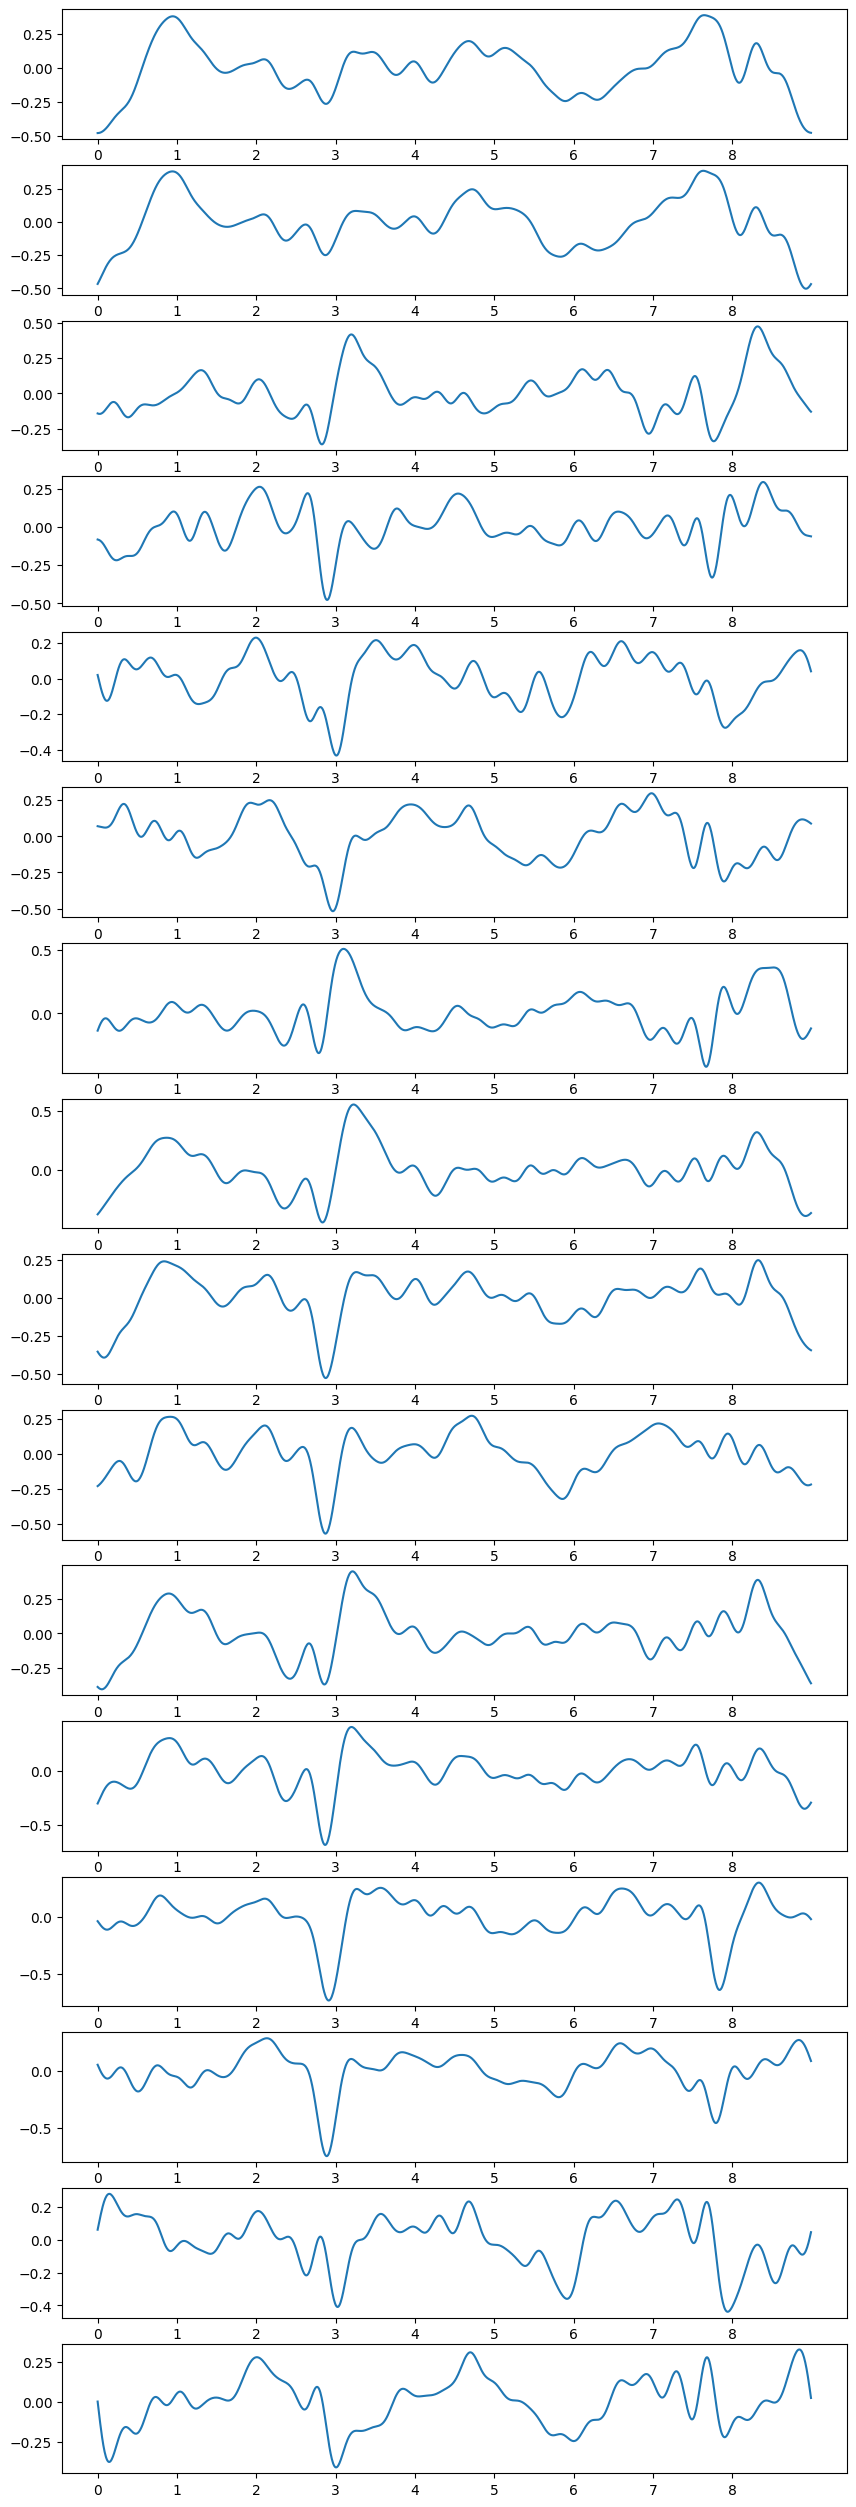

In [105]:
def plot_mrcp_across_channels_separate(epoch_mean):
    """
    Plots the MRCP for each channel.

    Args:
        mrcp (np.ndarray): 2D array of shape (n_samples, n_channels)
    """
    fig, axes = plt.subplots(EEG_NUM_CH, len(epoch_mean), figsize = (20, 40))
    
    for i, finger in enumerate(epoch_mean.keys()):
        time = np.arange(epoch_mean[finger].shape[0]) / EEG_FREQ
        mrcp = compute_mrcp(epoch_mean[finger])

        for ch in range(EEG_NUM_CH):
            axes[ch, i].plot(time, mrcp[:, ch])
            axes[ch, i].set_title(f'MRCP - For {finger} at channel {EEG_CH_NAMES[ch]}')
            
            axes[ch, i].set_xlabel('Time')
            axes[ch, i].set_ylabel('Amplitude [a.u]')

            axes[ch, i].axhline(0, color='black', linestyle = '-', linewidth=1)  # baseline line
            axes[ch, i].axvline(2, color='green', linestyle='-.', label="Contract")
            axes[ch, i].axvline(7, color='red', linestyle='--', label="Release")
            axes[ch, i].legend(loc='upper right')
        
    fig.tight_layout()

def plot_mrcp_across_channels_together(epoch_mean, single_plot_flag = 0):
    """
    Plots the MRCP for each channel.

    Args:
        mrcp (np.ndarray): 2D array of shape (n_samples, n_channels)
    """
    fig, axes = plt.subplots(EEG_NUM_CH, 1, figsize = (10, 40))
    single_plot_flag = 0

    for finger in epoch_mean.keys():
        time = np.arange(epoch_mean[finger].shape[0]) / EEG_FREQ
        mrcp = compute_mrcp(epoch_mean[finger])

        for ch in range(EEG_NUM_CH):
            axes[ch].plot(time, mrcp[:, ch], label = finger)
            
            if single_plot_flag == 1:
                axes[ch].set_title(f'MRCP - For {finger} at channel {EEG_CH_NAMES[ch]}')
                
                axes[ch].set_xlabel('Time')
                axes[ch].set_ylabel('Amplitude [a.u]')
                
                axes[ch].axhline(0, color='black', linestyle = '-', linewidth=1)  # baseline line
                axes[ch].axvline(2, color='green', linestyle='-.', label="Contract")
                axes[ch].axvline(7, color='red', linestyle='--', label="Release")
                axes[ch].legend(loc='lower left')
        
        single_plot_flag = 1
        
    fig.tight_layout()

def plot_mean_epoch_across_channels(data):
    n_channels = 16

    fig, axes = plt.subplots(n_channels, len(data), figsize = (20, 40))
    for i, finger in enumerate(data.keys()):
        time = np.arange(data[finger].shape[0]) / EEG_FREQ

        for ch in range(n_channels):
            axes[ch, i].plot(time, data[finger][:,ch])
            axes[ch, i].set_title(f'For {finger} at channel {EEG_CH_NAMES[ch]}')
            
            axes[ch, i].set_xlabel('Time')
            axes[ch, i].set_ylabel('Amplitude [a.u]')

            axes[ch, i].axvline(2, color='green', linestyle='-.', label="Contract")
            axes[ch, i].axvline(7, color='red', linestyle='--', label="Release")
            axes[ch, i].legend(loc='upper right')

    fig.tight_layout()

def plot_mean_epoch_single_channels(data, ch1 = 0, ch2 = 1, finger1 = None, finger2 = None):

    
    fig, axs = plt.subplots(
    1, 2,
    figsize=(mm_to_inches(162), mm_to_inches(60)),
    dpi=400,                     # IMPORTANT
    gridspec_kw={"wspace": 0.05}, # spacing between figures
    sharey=True
    )
    print('Channel Name :', EEG_CH_NAMES[ch1], 'and', EEG_CH_NAMES[ch2])
    
    time = np.arange(data[finger1].shape[0]) / EEG_FREQ

    axs[0].plot(time, data[finger1][:,ch1], color='royalblue', linewidth=1.0, label='Index finger')
    axs[0].set_xlim([0, 9])
    axs[0].set_ylim([-0.6, 0.6])
    axs[0].set_xticks(np.arange(0.0, 9.01, 1.0))
    axs[0].set_xlabel('Time (s)')
    axs[0].set_ylabel('Standardized EEG (a.u)')
    axs[0].axvline(2, color='salmon', linestyle='--', linewidth=1.0)
    axs[0].axvline(7, color='salmon', linestyle='--', linewidth=1.0)
    axs[0].grid(True, alpha=0.3)

    axs[1].plot(time, data[finger2][:,ch2], color='royalblue', linewidth=1.0, label='Index finger')
    axs[1].set_xlim([0, 9])
    #axs[1].set_ylim([-0.6, 0.6])
    axs[1].set_xticks(np.arange(0.0, 9.01, 1.0))
    axs[1].set_xlabel('Time (s)')
    #axs[1].set_ylabel('Standardized EEG (a.u)')
    axs[1].axvline(2, color='salmon', linestyle='--', linewidth=1.0)
    axs[1].axvline(7, color='salmon', linestyle='--', linewidth=1.0)
    axs[1].grid(True, alpha=0.3)
    
    plt.savefig(fr'images\Nicklas_wrist_EMG\Mean_EEG_epoch_{finger1}_{EEG_CH_NAMES[ch1]}_and_{finger2}_{EEG_CH_NAMES[ch2]}_report.pdf')

def plot_EEG_sequence_across_channels(data, st = 0, end = 9, fs = 125):
    xmin = st * fs
    xmax = end * fs
    n_samples, n_channels = data[xmin:xmax, :].shape
    col_size = 2 * n_channels
    row_size = 0.009 * n_samples 
    time = np.arange(n_samples) / fs

    fig, ax = plt.subplots(nrows = n_channels, ncols = 1, figsize = (row_size, col_size))
    
    for i in range(n_channels):
        ax[i].plot(time, data[xmin:xmax, i], label = f"EEG ch {EEG_CH_NAMES[i]}")
        ax[i].set_xticks(np.arange(0, 9, 1))

    plt.show()

plot_EEG_sequence_across_channels(EEG_epoch_mean['index'], st = 0, end = 9)

([<matplotlib.axis.XTick at 0x16c8b03d350>,
 [Text(0.0, 0, '0.0'),
  Text(0.1, 0, '0.1'),
  Text(0.2, 0, '0.2'),
  Text(0.30000000000000004, 0, '0.3'),
  Text(0.4, 0, '0.4'),
  Text(0.5, 0, '0.5'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.7000000000000001, 0, '0.7'),
  Text(0.8, 0, '0.8'),
  Text(0.9, 0, '0.9'),
  Text(1.0, 0, '1.0'),
  Text(1.1, 0, '1.1'),
  Text(1.2000000000000002, 0, '1.2'),
  Text(1.3, 0, '1.3'),
  Text(1.4000000000000001, 0, '1.4'),
  Text(1.5, 0, '1.5'),
  Text(1.6, 0, '1.6'),
  Text(1.7000000000000002, 0, '1.7'),
  Text(1.8, 0, '1.8'),
  Text(1.9000000000000001, 0, '1.9'),
  Text(2.0, 0, '2.0'),
  Text(2.1, 0, '2.1'),
  Text(2.2, 0, '2.2'),
  Text(2.3000000000000003, 0, '2.3'),
  Text(2.4000000000000004, 0, '2.4'),
  Text(2.5, 0, '2.5'),
  Text(2.6, 0, '2.6'),
  Text(2.7, 0, '2.7'),
  Text(2.8000000000000003, 0, '2.8'),
  Text(2.9000000000000004, 0, '2.9'),
  Text(3.0, 0, '3.0'),
  Text(3.1, 0, '3.1'),
  Text(3.2, 0, '3.2'),
  Text(3.3000000000000003, 0, '

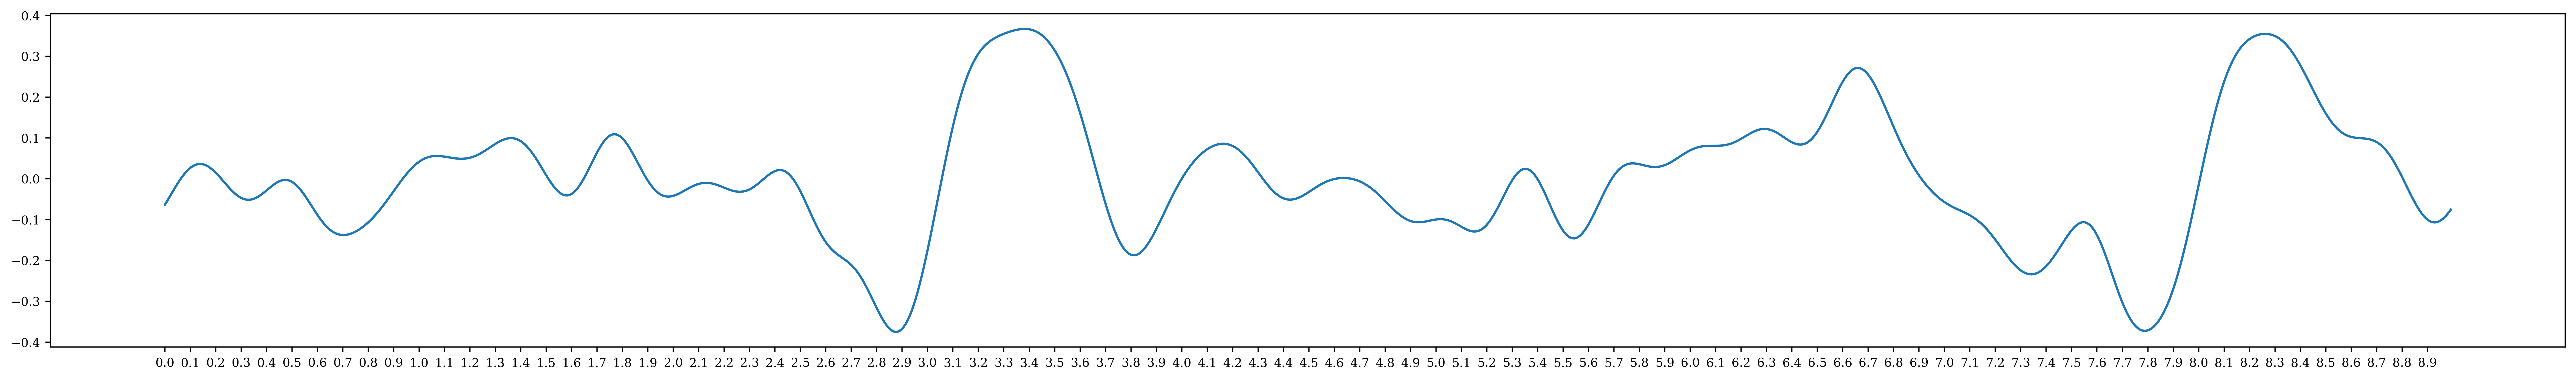

In [183]:
#ERD = compute_ERD_ERS_pfurtscheller(EEG_epoch['index'], fs = EEG_FREQ)
MRCP = compute_mrcp(EEG_epoch_mean['thumb'])

plt.figure(figsize=(30,4))
plt.plot(np.arange(MRCP.shape[0]) / EEG_FREQ, MRCP[:, 2])
plt.xticks(np.arange(0, 9, 0.1))

## Visualize topoplot with MNE

### 1. Load your custom electrode positions (.sfp)

In [168]:
channel_location_dir = str(parent_dir) + "\\utilities\\electrode_positions_16channel_modifed.sfp"

montage = mne.channels.read_custom_montage(channel_location_dir)
montage

<DigMontage | 0 extras (headshape), 0 HPIs, 0 fiducials, 16 channels>

### 2. Create MNE Info object

In [169]:
ch_names = montage.ch_names
n_channels = len(ch_names)

info = mne.create_info(
    ch_names = ch_names,
    sfreq = EEG_FREQ,
    ch_types = 'eeg'
)

# Attach your custom montage
info.set_montage(montage)

C:\Users\Bruger\AppData\Local\Temp\ipykernel_14880\1835121583.py:11: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  info.set_montage(montage)


<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, C3, C4, T5, T6, Cz, Fz, F7, F8, F3, F4, T3, T4, P3, P4
 chs: 16 EEG
 custom_ref_applied: False
 dig: 19 items (3 Cardinal, 16 EEG)
 highpass: 0.0 Hz
 lowpass: 62.5 Hz
 meas_date: unspecified
 nchan: 16
 projs: []
 sfreq: 125.0 Hz
>

### EKSTRA: ERD topo plot

In [184]:
ERD_T = MRCP.T # shape -> (channels, samples)

evoked = mne.EvokedArray(ERD_T, info, tmin=0)

In [176]:
# Keep to remain the scale
vmax = np.percentile(np.abs(ERD_T), 100)
vlim = (-vmax, vmax)

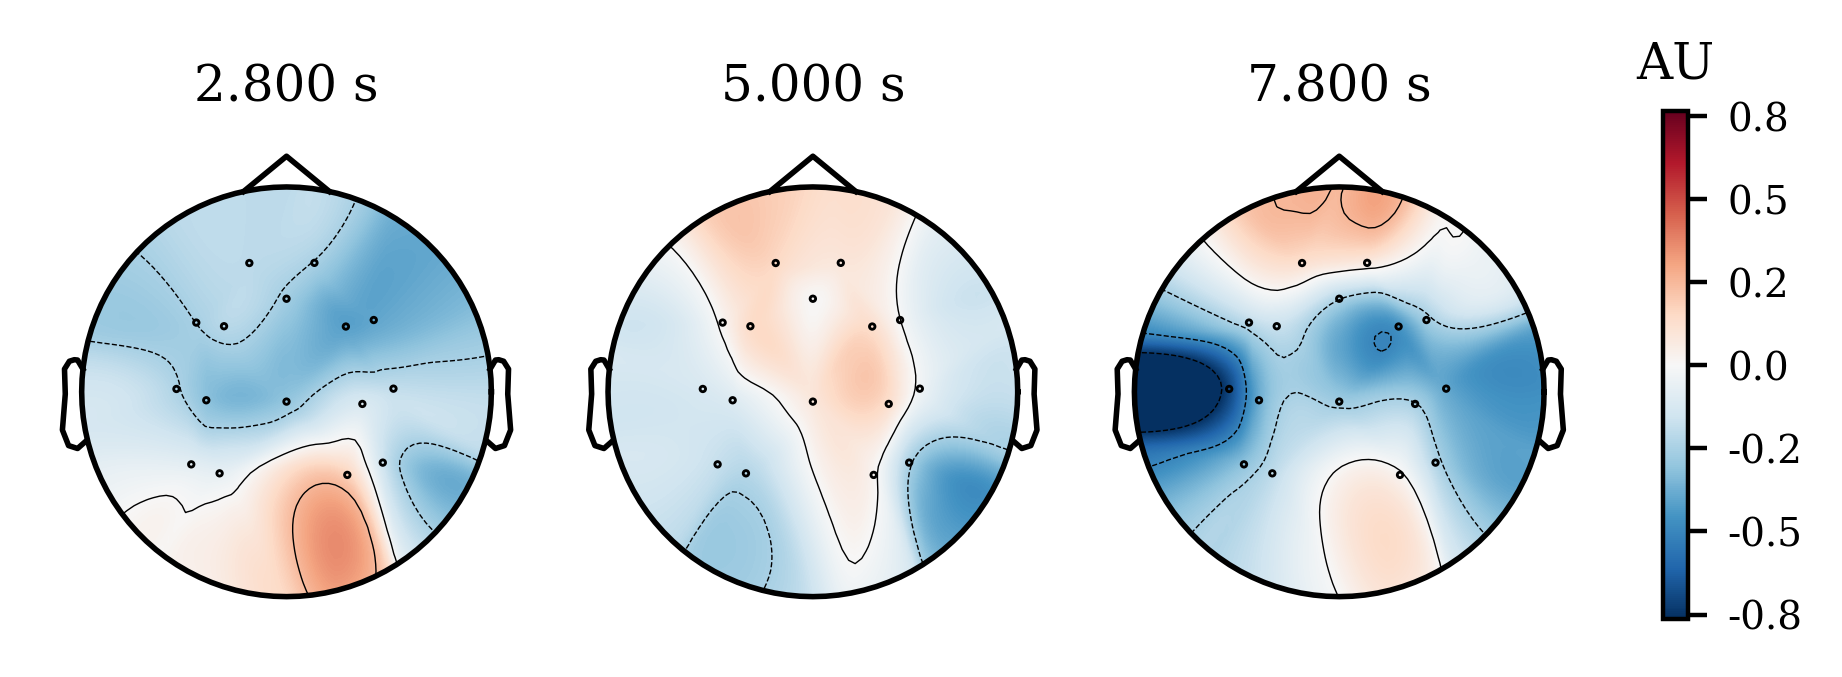

In [185]:
times = [2.8, 5.0, 7.8]   # seconds relative to your epoch start

fig = evoked.plot_topomap(
    times=times,
    ch_type='eeg',
    cmap='RdBu_r',
    size=1,
    time_unit='s',
    scalings=1,
    vlim=vlim,
    show=True
)


fig.savefig("mrcp_topomap_index.pdf", dpi=400, bbox_inches="tight")

### 3. Convert your numpy epochs into MNE Epochs

In [24]:
# Reshape, because MNE needs the dimensions of: (n_epochs, n_channels, n_samples)
select_data_epoch_index = EEG_epoch['index'].transpose(0, 2, 1).copy() * 1e-6   # convert µV → V
select_data_epoch_thumb = EEG_epoch['thumb'].transpose(0, 2, 1).copy() * 1e-6   # convert µV → V 

epochs_mne_index = mne.EpochsArray(select_data_epoch_index, info=info, verbose=False)
epochs_mne_thumb = mne.EpochsArray(select_data_epoch_thumb, info=info, verbose=False)

# Compute evoked response (average across epochs)
evoked_index = epochs_mne_index.average()
evoked_thumb = epochs_mne_thumb.average()

In [76]:
print(f"select_data_epoch_index shape: {select_data_epoch_index.data.shape}\n"
      f"evoked_index shape: {evoked_index.data.shape}")

select_data_epoch_index shape: (105, 16, 1125)
evoked_index shape: (16, 1125)


### 4. Create a beautiful topoplot

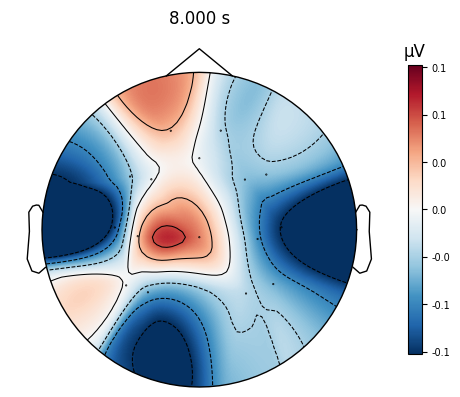

In [85]:
# Time (in seconds) you want to visualize
time_to_plot = 8

fig = evoked_index.plot_topomap(
    times=[time_to_plot],
    ch_type='eeg',
    cmap='RdBu_r',
    size=3,
    show=False
)

plt.show()

### 5. Multiple topoplots across time

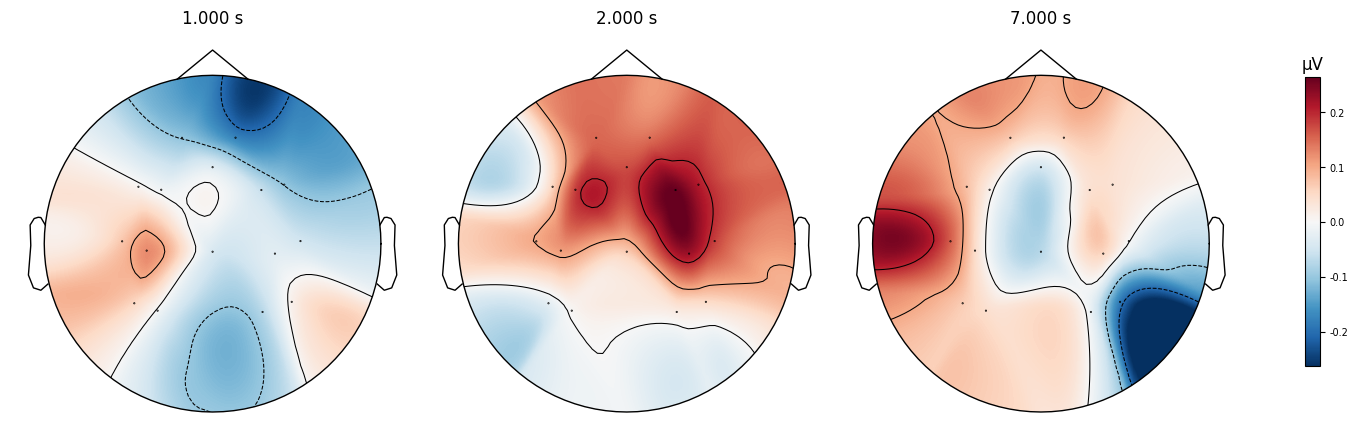

In [24]:
times = [1, 2, 7]  # seconds

fig = evoked_index.plot_topomap(
    times=times,
    ch_type='eeg',
    cmap='RdBu_r',
    size=3,
    show=False
)

plt.show()

### 7. Compare two classes: thumb vs index

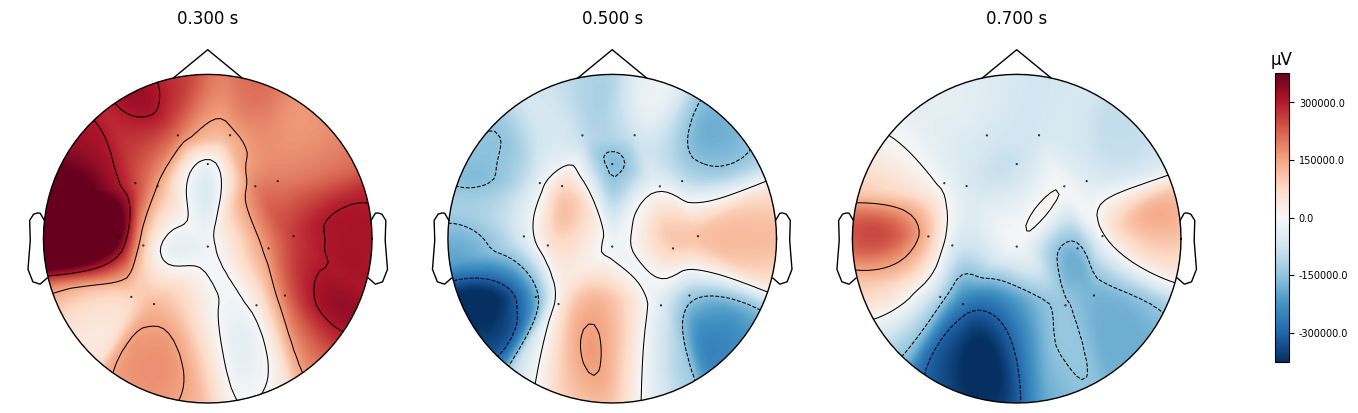

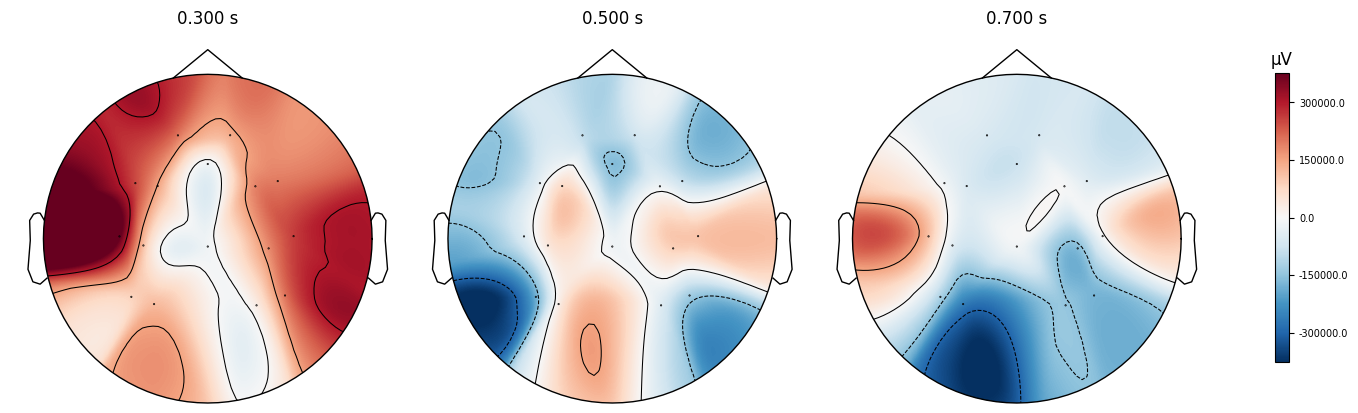

In [20]:
# Difference map
evoked_diff = mne.combine_evoked([evoked_index, evoked_thumb], weights=[1, -1])

evoked_diff.plot_topomap(times=[0.3, 0.5, 0.7], cmap='RdBu_r', size=3)


## Step-by-step solution: windowed topomaps

## 1. Extract window-averaged topographies

In [67]:
# Define time window 
time_windows = [
    (0.6, 1.0),
    (2.6, 3.0),
    (7.6, 8.0)
]

topomaps = []
times_for_plot = []

for tmin, tmax in time_windows:
    # Crop evoked to window
    evoked_win = evoked_index.copy().crop(tmin=tmin, tmax=tmax)

    # Average across time → (n_channels,)
    topo = evoked_win.data.mean(axis=1)
    topomaps.append(topo)

    # For labeling only
    times_for_plot.append((tmin + tmax) / 2)

## 3. Plot them as a row of scalp maps

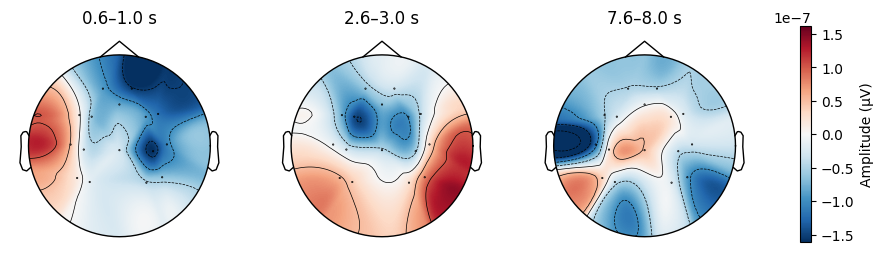

In [68]:
fig, axes = plt.subplots(1, len(topomaps), figsize=(12, 4))
vlim = max(abs(np.concatenate(topomaps)))

for i, topo in enumerate(topomaps):
    im, _ = mne.viz.plot_topomap(
        topo,
        evoked_index.info,
        axes=axes[i],
        cmap='RdBu_r',
        vlim=(-vlim, vlim),
        show=False
    )
    axes[i].set_title(f"{time_windows[i][0]}–{time_windows[i][1]} s")

# ---- Add shared colorbar ----
cbar = fig.colorbar(im, ax=axes, shrink=0.7)
cbar.set_label("Amplitude (µV)")

#plt.tight_layout()
plt.show()
